In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data.csv')
print(df.shape)

(569, 33)


In [ ]:
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Drop the empty last column
df = df.drop(columns=['Unnamed: 32'])

# Check diagnosis column values
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
# Encode M/B as 1/0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Confirm no missing values
print(df.isnull().sum().sum(), "missing values")


0 missing values


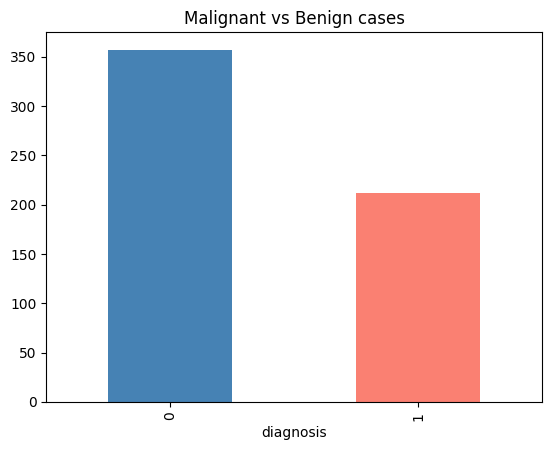

In [ ]:
# Chart 1 — diagnosis distribution
df['diagnosis'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Malignant vs Benign cases')
plt.savefig('chart1_diagnosis.png')
plt.show()

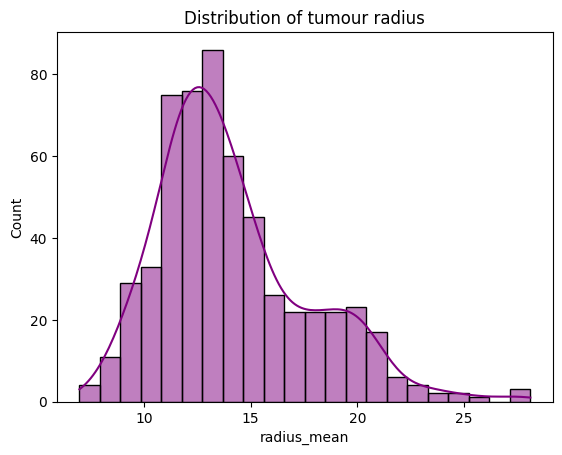

In [ ]:
# Chart 2 — tumour size distribution
sns.histplot(df['radius_mean'], kde=True, color='purple')
plt.title('Distribution of tumour radius')
plt.savefig('chart2_radius.png')
plt.show()

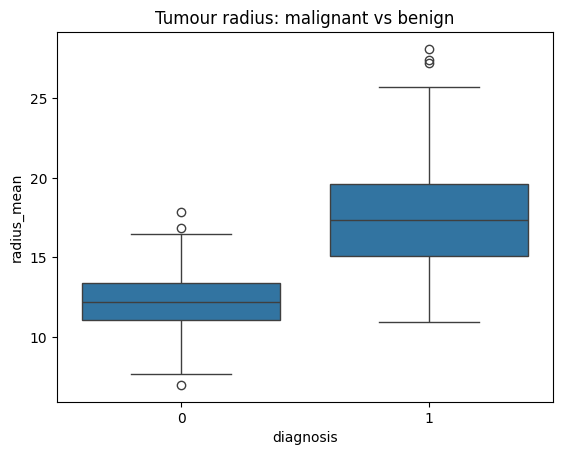

In [ ]:
# Chart 3 — malignant vs benign by radius
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title('Tumour radius: malignant vs benign')
plt.savefig('chart3_boxplot.png')
plt.show()

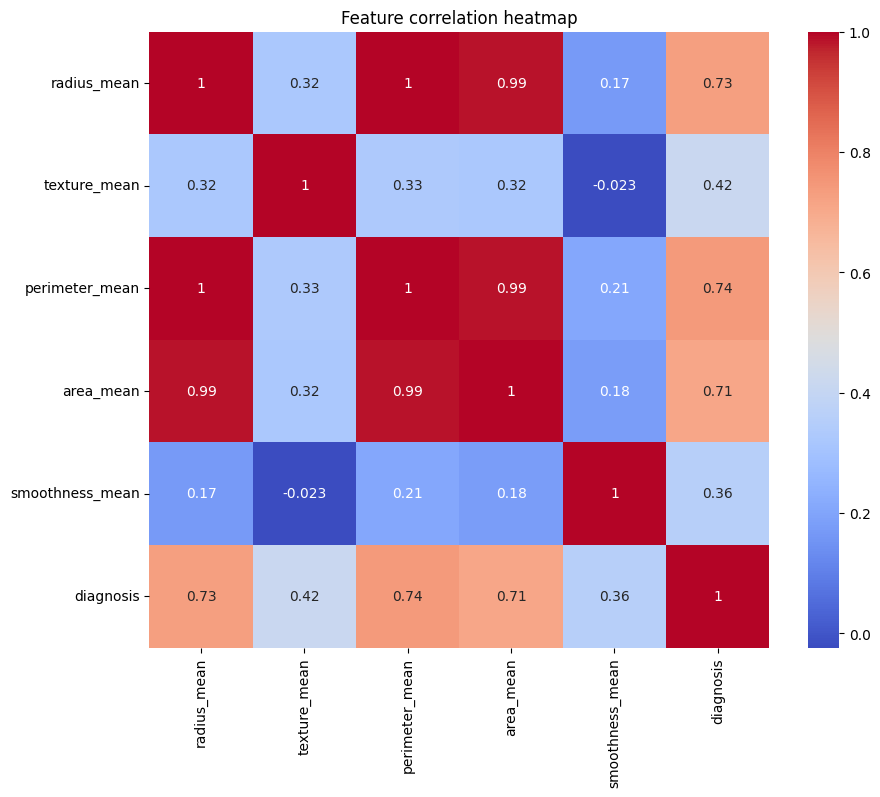

In [ ]:
# Chart 4 — correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[['radius_mean','texture_mean','perimeter_mean',
    'area_mean','smoothness_mean','diagnosis']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature correlation heatmap')
plt.savefig('chart4_heatmap.png')
plt.show()

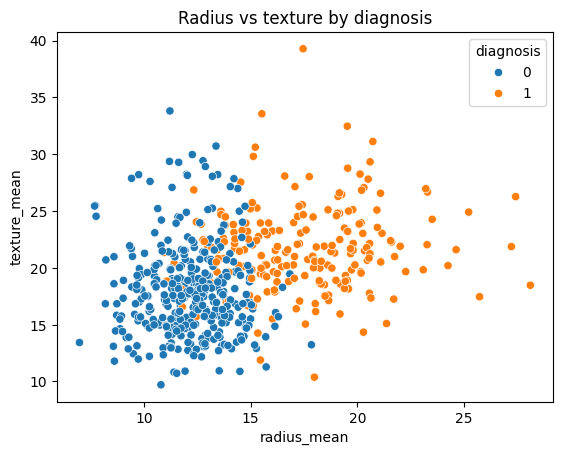

In [ ]:
# Chart 5 — scatter plot
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df)
plt.title('Radius vs texture by diagnosis')
plt.savefig('chart5_scatter.png')
plt.show()

In [ ]:
import os
files = [f for f in os.listdir() if f.endswith('.png')]
print(files)

['chart4_heatmap.png', 'chart1_diagnosis.png', 'chart3_boxplot.png', 'chart2_radius.png', 'chart5_scatter.png']


In [ ]:
# Summary of findings
print("""
FINDINGS FROM BREAST CANCER EDA
================================
Finding 1: Dataset contains 357 benign and 212 malignant cases —
a 63/37 class distribution.

Finding 2: Malignant tumours have a significantly larger mean radius
compared to benign tumours, suggesting tumour size is a key indicator.

Finding 3: Area and perimeter are highly correlated with radius (r > 0.9),
indicating strong feature relationships in the dataset.
""")


FINDINGS FROM BREAST CANCER EDA
Finding 1: Dataset contains 357 benign and 212 malignant cases — 
a 63/37 class distribution.

Finding 2: Malignant tumours have a significantly larger mean radius 
compared to benign tumours, suggesting tumour size is a key indicator.

Finding 3: Area and perimeter are highly correlated with radius (r > 0.9), 
indicating strong feature relationships in the dataset.

